# Day 1

In [2]:
import sys, platform

print('Python', sys.version)
print(platform.system())
print('셀 실행: shift + Enter')

Python 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:29:10) [GCC 14.3.0]
Linux
셀 실행: shift + Enter


In [3]:
import numpy as np
import pandas as pd
import torch

print('PyTorch', torch.__version__)
print('CUDA:', torch.cuda.is_available())

PyTorch 2.8.0+cu128
CUDA: True


In [4]:
%pwd

'/workspace'

## 확률 모델링

In [5]:
from sklearn.datasets import load_iris

iris = load_iris()
print(type(iris))
print(iris.keys())

print(iris.target_names, '->', np.unique(iris.target))
print(iris.data.shape)
iris.frame = pd.DataFrame(iris.data, columns=iris.feature_names)
iris.frame['target'] = iris.target
iris.frame.head()

<class 'sklearn.utils._bunch.Bunch'>
dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
['setosa' 'versicolor' 'virginica'] -> [0 1 2]
(150, 4)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [6]:
from sklearn.linear_model import LogisticRegression

최대학습횟수 = 1000
model = LogisticRegression(max_iter=최대학습횟수)
model.fit(iris.data, iris.target)

예측 = model.predict(iris.data)
채점 = 예측 == iris.target
print(f'{채점.sum()}/{len(채점)} = {채점.mean():.1%}')
오답필터 = np.logical_not(채점) # True <-> False
iris.frame.assign(예측=예측)[오답필터]

146/150 = 97.3%


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,예측
70,5.9,3.2,4.8,1.8,1,2
77,6.7,3.0,5.0,1.7,1,2
83,6.0,2.7,5.1,1.6,1,2
106,4.9,2.5,4.5,1.7,2,1


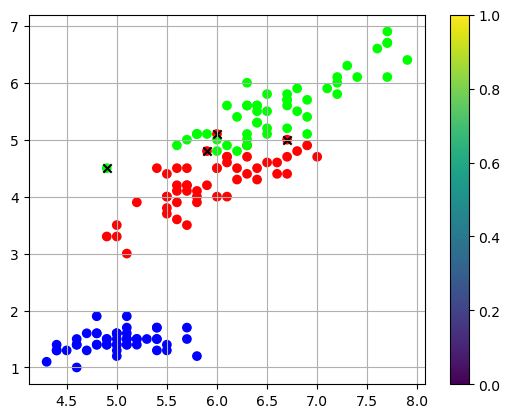

In [7]:
import matplotlib.pyplot as plt

plt.scatter(x=iris.data[:, 0], y=iris.data[:, 2], c=iris.target, cmap='brg')
# 오답 표시
plt.scatter(x=iris.data[오답필터, 0], y=iris.data[오답필터, 2], c='k', marker='x')
plt.colorbar()
plt.grid()
plt.show()

In [8]:
from scipy.special import softmax
# 학습된 매개변수
W = model.coef_ # 가중치(weights) 또는 계수(coefficients)
b = model.intercept_ # 절편(intercept) 또는 편향(bias)
print(f'W: {W.shape} b: {b.shape}')

Z = iris.data @ W.T + b # X @ W.T + b
assert np.allclose(Z, model.decision_function(iris.data))
예측 = np.argmax(Z, axis=1) # 가장 큰 값의 인덱스(위치)
assert np.all(예측 == model.predict(iris.data))
# # 소프트맥스
# softmax = lambda Z: np.exp(Z) / np.exp(Z).sum(axis=1, keepdims=True)
pd.DataFrame(softmax(Z, axis=1), columns=iris.target_names).round(3).assign(예측=예측, 정답=iris.target)[오답필터]

W: (3, 4) b: (3,)


,setosa,versicolor,virginica,예측,정답
70,0.002,0.440,0.557,2,1
77,0.001,0.481,0.518,2,1
83,0.000,0.350,0.650,2,1
106,0.006,0.514,0.481,1,2


## MNIST 

손글씨 숫자 이미지 데이터셋. 딥러닝의 "Hello World"

In [9]:
from torchvision.datasets import MNIST

mnist = {}
for split in ['train', 'test']:
    mnist[split] = MNIST(root='data', train=(split=='train'), download=True)
    print(f'{split:<5}: {len(mnist[split]):,}')

train: 60,000
test : 10,000


## 전처리

In [ ]:
sample, label = mnist['train'][0]
print(type(sample), sample.size, f'label: {label}')

xi = np.array(sample)
print(type(xi), xi.shape, xi.dtype, xi.min(), xi.max())
# ToTensor() 스타일 전처리
xi = xi.astype(np.float32)
xi /= 255
xi = xi.reshape(1, 28, 28) #  ToTensor() 스타일 채널 추가
xi = torch.from_numpy(xi) # numpy -> torch
print(type(xi), xi.shape, xi.dtype, xi.min(), xi.max())

display(sample)

<class 'PIL.Image.Image'> (28, 28) label: 5
<class 'numpy.ndarray'> (28, 28) uint8 0 255
<class 'torch.Tensor'> torch.Size([1, 28, 28]) torch.float32 tensor(0.) tensor(1.)


In [17]:
import torchvision.transforms as transforms

xi = transforms.ToTensor()(sample)
print(type(sample), '->', type(xi))
print(xi.shape, xi.dtype, xi.min(), xi.max())

<class 'PIL.Image.Image'> -> <class 'torch.Tensor'>
torch.Size([1, 28, 28]) torch.float32 tensor(0.) tensor(1.)


In [6]:
%run load_mnist.py

train: 60,000
test : 10,000


In [ ]:
sample, label = mnist['train'][0]
print(type(sample), sample.shape, sample.dtype, f'label: {label}')
# 텐서 형상 조정 (review)
# 1 x 28 x 28 = ? (-1)
for xi in [sample, sample.reshape(-1), sample.reshape(1, -1)]:
    print(f'총 원소수: {xi.numel()}') # numel = number of elements
    print(xi.shape)

<class 'torch.Tensor'> torch.Size([1, 28, 28]) torch.float32 label: 5
총 원소수: 784
torch.Size([1, 28, 28])
총 원소수: 784
torch.Size([784])
총 원소수: 784
torch.Size([1, 784])


## 모델

In [60]:
import torch.nn as nn # 신경망(neural network) 모듈

model = nn.Sequential(
    nn.Flatten(), # (28, 28) -> (784,)
    nn.Linear(in_features=28*28, out_features=512),
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=10)
)
print(model)

손실함수 = nn.CrossEntropyLoss()

%run load_mnist.py
sample, label = mnist['train'][0]
print(sample.shape, '->', sample.reshape(1, -1).shape)
Xs = sample.reshape(1, -1) # (1, 28, 28) -> (1, ?)
outputs = model(Xs)
print(outputs.shape)
print(f'손실: {손실함수(outputs, torch.tensor([label])):.3f}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=10, bias=True)
)
train: 60,000
test : 10,000
torch.Size([1, 28, 28]) -> torch.Size([1, 784])
torch.Size([1, 10])
손실: 2.242


## 미니 배치

In [52]:
from torch.utils.data import DataLoader

배치크기 = 128
data_loader = {}
data_loader['train'] = DataLoader(mnist['train'], batch_size=배치크기, shuffle=True)#, drop_last=True)
print(f'배치크기: {배치크기} -> 배치 수: {len(data_loader["train"])} = {len(mnist["train"])}/{배치크기}')
assert len(data_loader['train']) == np.ceil(len(mnist['train']) / 배치크기)

for X_batch, y_batch in data_loader['train']:
    try:
        assert 배치크기 == len(X_batch) == len(y_batch)
    except AssertionError:
        print(f'배치 크기 불일치: {배치크기} != {len(X_batch)}')

배치크기: 128 -> 배치 수: 469 = 60000/128
배치 크기 불일치: 128 != 96


In [59]:
import time

# 배치 크기에 따른 손실과 계산 시간 측정  
손실 = {}
for 배치크기 in [1, 10, 100, 300, 600, 1000, 6000, 60000]:
    print(f'배치크기: {배치크기}')
    data_loader = DataLoader(mnist['train'], batch_size=배치크기, shuffle=False)
    X_batch, y_batch = next(iter(data_loader))
    start_time = time.time()
    outputs = model(X_batch.reshape(-1, 784))
    loss = 손실함수(outputs, y_batch)
    손실[배치크기] = {'loss': loss.item(), 'time (ms)': (time.time() - start_time) * 1000}

pd.DataFrame(손실).round(2)

배치크기: 1
배치크기: 10
배치크기: 100
배치크기: 300
배치크기: 600
배치크기: 1000
배치크기: 6000
배치크기: 60000


,1,10,100,300,600,1000,6000,60000
loss,2.46,2.30,2.28,2.29,2.29,2.29,2.29,2.29
time (ms),30.89,14.42,0.86,1.59,1.67,3.85,17.87,176.41


## 학습

In [75]:
import torch.nn as nn # 신경망(neural network) 모듈

model = nn.Sequential(
    nn.Flatten(), # (28, 28) -> (784,)
    nn.Linear(in_features=28*28, out_features=512),
    nn.ReLU(),
    nn.Linear(in_features=512, out_features=10)
)
print(model)
손실함수 = nn.CrossEntropyLoss()
최적화기법 = torch.optim.RMSprop(model.parameters(), lr=1e-3)

# 학습
data_loader = {}
data_loader['train'] = DataLoader(mnist['train'], batch_size=128, shuffle=True)
loss_history = []
에폭수 = 5
for epoch in range(에폭수):
    for X_batch, y_batch in data_loader['train']:
        # 1. 손실 계산
        outputs = model(X_batch)
        loss = 손실함수(outputs, y_batch)
        loss_history.append(loss.item())
        # 2. 경사 산출 (역전파)
        최적화기법.zero_grad() # 경사 초기화
        loss.backward()
        # 3. 매개변수 갱신
        최적화기법.step()
    print(f'손실 (에폭 {epoch+1}/{에폭수}): {loss.item():.3f}')

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=512, bias=True)
  (2): ReLU()
  (3): Linear(in_features=512, out_features=10, bias=True)
)
손실 (에폭 1/5): 0.136
손실 (에폭 2/5): 0.015
손실 (에폭 3/5): 0.026
손실 (에폭 4/5): 0.034
손실 (에폭 5/5): 0.014


## 평가

In [76]:
data_loader['test'] = DataLoader(mnist['test'], batch_size=128, shuffle=False)

all_outputs = []; all_targets = []
with torch.inference_mode(): # 평가 모드 (역전파 불필요)
    for X_batch, y_batch in data_loader['test']:
        outputs = model(X_batch)
        all_outputs.append(outputs)
        all_targets.append(y_batch)

all_outputs = torch.cat(all_outputs, dim=0) # cat (concatenate) = 이어붙이기
all_targets = torch.cat(all_targets, dim=0)
print(all_outputs.shape)
예측 = torch.argmax(all_outputs, dim=1)
채점 = 예측 == all_targets
print(f'{채점.sum()}/{len(채점)} = {채점.float().mean():.1%}')
pd.DataFrame(all_outputs).assign(예측=예측, 정답=all_targets).round(3).head()

torch.Size([10000, 10])
9807/10000 = 98.1%


,0,1,2,3,4,5,6,7,8,9,예측,정답
0,-7.415,-7.483,-3.049,-1.427,-15.309000,-7.091,-18.364,9.013,-6.493,-3.347,7,7
1,-10.523,0.714,9.549,-4.469,-23.124001,-5.916,-5.968,-14.957,-2.896,-19.493,2,2
2,-11.186,5.586,-4.565,-6.606,-5.320000,-6.379,-4.643,-2.046,-2.243,-8.949,1,1
3,8.204,-9.304,-2.323,-7.917,-8.729000,-6.863,-4.408,-4.974,-12.311,-4.889,0,0
4,-5.676,-12.830,-3.882,-9.795,6.893000,-8.626,-5.342,-1.992,-7.320,2.502,4,4


## nn.Linear

$$
\text{nn.Linear} = X \cdot W^{\top} + b
$$

In [ ]:
f = nn.Linear(in_features=784, out_features=10)

X_batch, y_batch = next(iter(data_loader['train']))
X_batch = X_batch.reshape(-1, 784) # (128, 28, 28) -> (128, 784)
outputs = f(X_batch)
W = f.weight
b = f.bias
print(f'W: {W.shape} b: {b.shape}')
Z = X_batch @ W.T + b
assert torch.allclose(Z, outputs)

W: torch.Size([10, 784]) b: torch.Size([10])


## Keras

In [ ]:
import os
# 환경 변수 설정
os.environ['KERAS_BACKEND'] = 'torch'

import torch
import keras

print('PyTorch', torch.__version__)
print('Keras', keras.__version__)

PyTorch 2.8.0+cu128
Keras 3.10.0


## keras.layers.Dense

$$
\text{keras.layers.Dense} = X \cdot W + b
$$

In [ ]:
f = keras.layers.Dense(10)

X_batch, y_batch = next(iter(data_loader['train']))
X_batch = X_batch.reshape(-1, 784)

outputs = f(X_batch)
print(type(outputs), outputs.shape)
W, b = f.get_weights() # 매개변수 획득
print(f'W: {W.shape} b: {b.shape}')
Z = X_batch @ W + b # nn.Linear.weight = keras.layers.Dense.kernel.T
assert np.allclose(Z, outputs.detach().cpu().numpy(), atol=1e-5)

<class 'torch.Tensor'> torch.Size([128, 10])
W: (784, 10) b: (10,)


/tmp/ipykernel_77291/1570679033.py:10: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  Z = X_batch @ W + b


## Keras 모델

In [97]:
model = keras.Sequential([
    keras.Input(shape=(1, 28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(10)
])
model.summary()

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-3),
    metrics=['accuracy'] # 손실 외 추가 평가 지표
)

%run load_mnist.py
data_loader = {}
for split in mnist.keys():
    data_loader[split] = DataLoader(
        mnist[split], batch_size=128, shuffle=(split=='train'))
    
history = model.fit(data_loader['train'], epochs=5)

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_9 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

train: 60,000
test : 10,000
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8671 - loss: 0.4574
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 22ms/step - accuracy: 0.9658 - loss: 0.1173
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9791 - loss: 0.0741
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 20ms/step - accuracy: 0.9851 - loss: 0.0490
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.9893 - loss: 0.0364


In [98]:
test_results = model.evaluate(data_loader['test'], return_dict=True)
pd.Series(test_results).round(3)

 1/79 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9922 - loss: 0.0268

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9782 - loss: 0.0702


accuracy    0.982
loss        0.059
dtype: float64

In [ ]:
X_batch, y_batch = next(iter(data_loader['test']))
outputs = model(X_batch) # 연산은 벡엔드가 수행
print(type(outputs), outputs.shape)

<class 'torch.Tensor'> torch.Size([128, 10])


Q: 근데 왜 파이토치 많이 쓰나?

In [102]:
import numpy as np

x = np.linspace(0, 1, 5)
print(x)
print(type(x), x.shape, x.dtype)

[0.   0.25 0.5  0.75 1.  ]
<class 'numpy.ndarray'> (5,) float64


In [103]:
import torch

x = torch.linspace(0, 1, 5)
print(x)
print(type(x), x.shape, x.dtype)

tensor([0.0000, 0.2500, 0.5000, 0.7500, 1.0000])
<class 'torch.Tensor'> torch.Size([5]) torch.float32


## Fashion MNIST

train: 60,000
test : 10,000


,0,1,2,3,4,5,6,7,8,9
label,T-shirt/top,Trouser,Pullover,Dress,Coat,Sandal,Shirt,Sneaker,Bag,Ankle boot


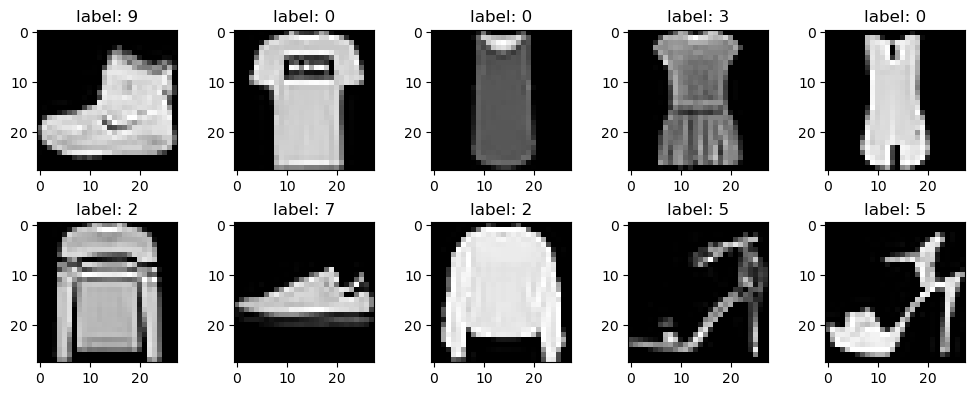

In [ ]:
from torchvision.datasets import FashionMNIST
import torchvision.transforms as transforms

전처리 = transforms.ToTensor()

fashion_mnist = {}
for split in ['train', 'test']:
    fashion_mnist[split] = FashionMNIST(
        root='data', train=(split=='train'), download=True, transform=전처리)
    print(f'{split:<5}: {len(fashion_mnist[split]):,}')

display(pd.DataFrame({'label': FashionMNIST.classes}).T)
plt.figure(figsize=(10, 4))
for i, (sample, label) in zip(range(10), fashion_mnist['train']):
    # print(type(sample), sample.shape, sample.dtype)
    sample = sample.squeeze() # (1, 28, 28) -> (28, 28)
    # print(type(sample), sample.shape, sample.dtype)
    # 이미지 시각화
    plt.subplot(2, 5, i + 1) # 2행 5열의 i+1번째 위치
    plt.imshow(sample, cmap='gray')
    plt.title(f'label: {label}')

plt.tight_layout()
plt.show()

In [117]:
model = keras.Sequential([
    keras.Input(shape=(1, 28, 28)),
    keras.layers.Flatten(),
    keras.layers.Dense(512, activation='relu'),
    keras.layers.Dense(10)
])
model.summary()

model.compile(
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-3),
    metrics=['accuracy'] # 손실 외 추가 평가 지표
)

data_loader = {}
for split in fashion_mnist.keys():
    data_loader[split] = DataLoader(
        fashion_mnist[split], batch_size=128, shuffle=(split=='train'))
    
history = model.fit(data_loader['train'], epochs=5)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_10 (Flatten)            │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_25 (Dense)                │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 11s 23ms/step - accuracy: 0.7419 - loss: 0.7471
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8553 - loss: 0.3944
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8709 - loss: 0.3507
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8838 - loss: 0.3193
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 10s 21ms/step - accuracy: 0.8913 - loss: 0.2960


In [118]:
test_results = model.evaluate(data_loader['test'], return_dict=True)
pd.Series(test_results).round(3)

79/79 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.8656 - loss: 0.3806


accuracy    0.864
loss        0.385
dtype: float64